# SkinTell — 04 Evaluation
Evaluate the trained model: confusion matrix, per-class metrics, and sample predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

CLEAN_DIR   = '../data/processed'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASS_NAMES = ['clear', 'mild', 'moderate', 'severe']

model = tf.keras.models.load_model('../models/best_model.keras')
print('Model loaded successfully')

Model loaded successfully


## 1. Predictions on Validation Set

In [2]:
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_gen = val_datagen.flow_from_directory(
    CLEAN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    seed=42, shuffle=False
)

y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

print(f'Overall Validation Accuracy: {np.mean(y_pred == y_true):.2%}')

Found 274 images belonging to 4 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 307ms/step
Overall Validation Accuracy: 52.19%


## 2. Classification Report

In [3]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       clear       0.63      0.44      0.52        96
        mild       0.53      0.59      0.56       124
    moderate       0.33      0.57      0.42        35
      severe       0.89      0.42      0.57        19

    accuracy                           0.52       274
   macro avg       0.59      0.50      0.52       274
weighted avg       0.56      0.52      0.53       274



## 3. Confusion Matrix

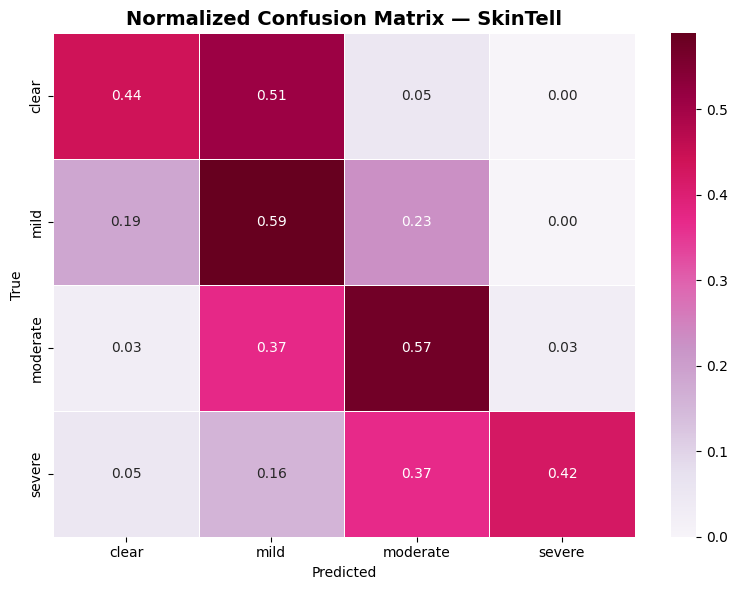

In [4]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='PuRd', linewidths=0.5, ax=ax)
ax.set_title('Normalized Confusion Matrix — SkinTell', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('../plots/confusion_matrix.png', dpi=150)
plt.show()

## 4. Sample Predictions with Confidence Scores

Found 274 images belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


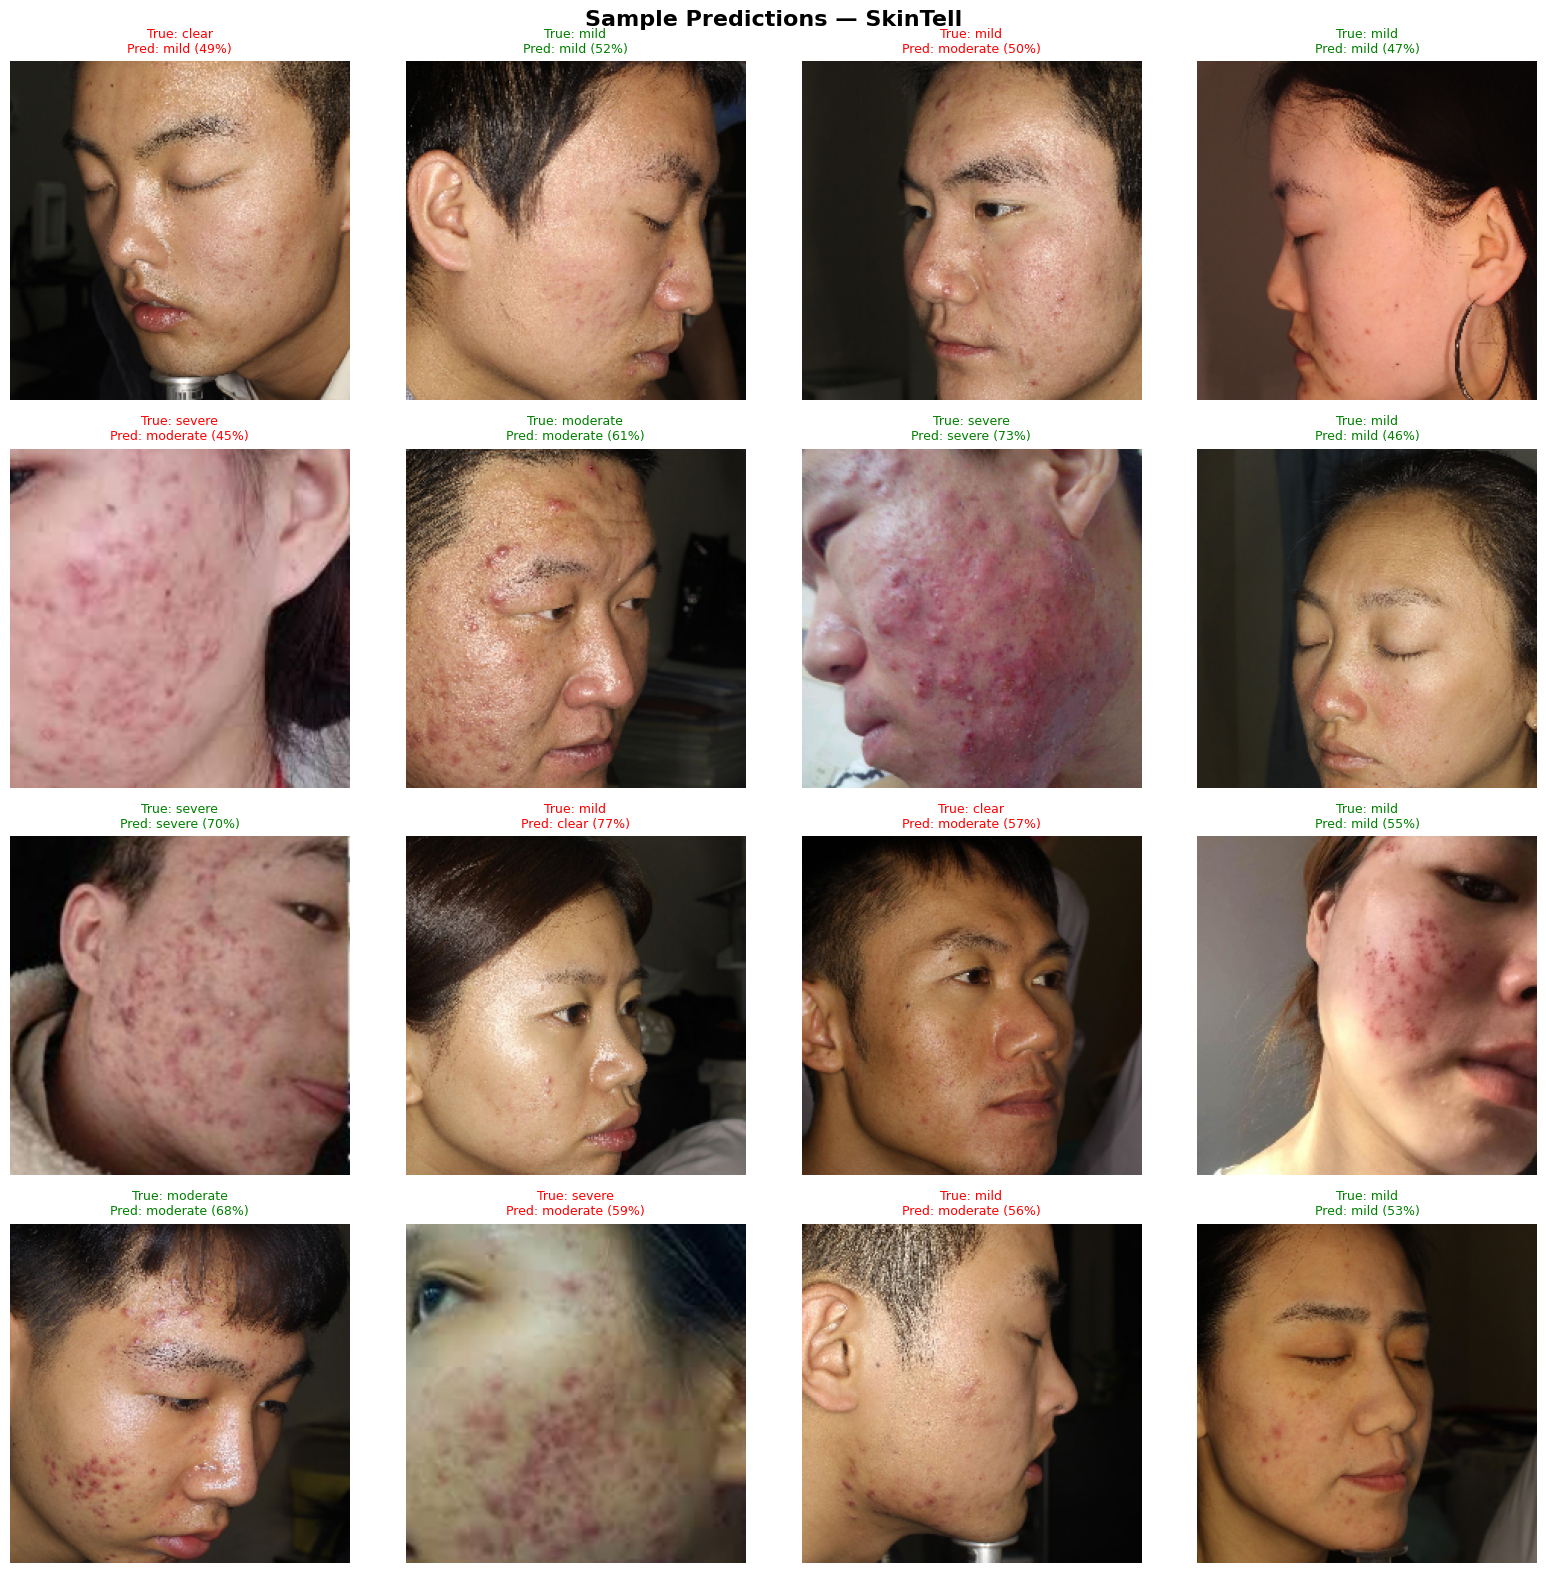

Green = correct | Red = incorrect


In [5]:
val_gen_display = val_datagen.flow_from_directory(
    CLEAN_DIR, target_size=IMG_SIZE, batch_size=16,
    class_mode='categorical', subset='validation',
    seed=42, shuffle=True
)

images, labels = next(val_gen_display)
preds = model.predict(images)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Sample Predictions — SkinTell', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    confidence = np.max(preds[i])
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.0%})',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../plots/sample_predictions.png', dpi=150)
plt.show()
print('Green = correct | Red = incorrect')